n=500, максимальный вес: 92
n=2000, максимальный вес: 110
n=10000, максимальный вес: 110


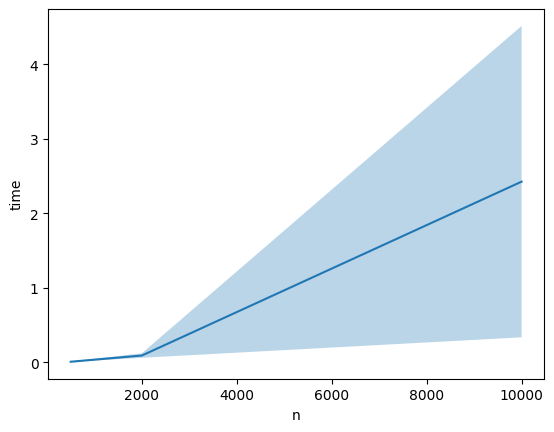

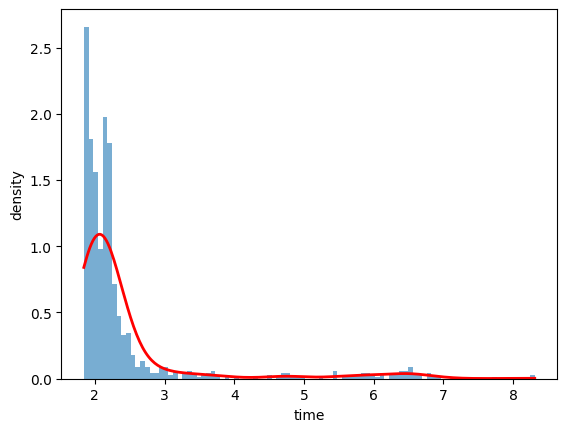

p-value: 5.750601092875176e-147
Нормальность отвергается


In [2]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde,normaltest

def max_weight(n):
    a = []
    for _ in range(n):
        s = random.randint(0, 10)
        e = s + random.randint(1, 10)
        w = random.randint(1, 10)
        a.append((s, e, w))

    start_time = time.perf_counter()

    a.sort(key=lambda x: x[1])
    dp = [0] * (n + 1)

    for i in range(1, n + 1):
        s, e, w = a[i - 1]
        j = 0
        for k in range(i - 1, 0, -1):
            if a[k - 1][1] <= s:
                j = k
                break
        dp[i] = max(dp[i - 1], dp[j] + w)

    return time.perf_counter() - start_time,dp[n]


sizes = [500, 2000, 10000]
MO = []
SKO = []

for n in sizes:
    times = []
    for _ in range(1000):
        t,weight = max_weight(n)
        times.append(t)
    print(f'n={n}, максимальный вес: {weight}')

    MO.append(np.mean(times))
    SKO.append(np.std(times))

plt.plot(sizes, MO)
plt.fill_between(
    sizes,
    np.array(MO) - 2 * np.array(SKO),
    np.array(MO) + 2 * np.array(SKO),
    alpha=0.3
)
plt.xlabel("n")
plt.ylabel("time")
plt.show()

fig, ax = plt.subplots()
ax.hist(times, bins='auto', density=True, alpha=0.6)

kde = gaussian_kde(times)
x = np.linspace(min(times), max(times), 300)
ax.plot(x, kde(x), color="red", linewidth=2)

ax.set_xlabel("time")
ax.set_ylabel("density")
plt.show()

k2, p_value = normaltest(times)

print(f"p-value: {p_value}")
if p_value > 0.05:
    print("Нормальность не отвергается")
else:
    print("Нормальность отвергается")